# Exploratory Data Analysis

Profiling the full corpus before any modeling, to establish what the task actually demands and what a meaningful evaluation looks like.

## The task

Speech systems cannot pronounce written text directly. `$3.16` has to become *three dollars sixteen cents*, `12:47` becomes *twelve forty-seven*, `1987` becomes *nineteen eighty-seven*. Conventionally these mappings are specified by hand as linguistic grammars, one set per language. This project examines whether they can be learned from labelled examples instead.

Given raw written text (`before`), predict the spoken form (`after`).

## Questions this notebook answers

1. How large is the corpus and how clean is it
2. How are token classes distributed
3. What proportion of tokens actually require transformation, and what does that imply for evaluation
4. Which classes carry the transformation burden
5. Is the mapping from written to spoken form deterministic
6. How much unseen vocabulary should a model expect at inference time

The answers to 3 and 5 determine the entire evaluation strategy, so they are the ones worth reading closely.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42

RAW = Path('../data/raw/en_train.csv')
ASSETS = Path('../assets')
ASSETS.mkdir(exist_ok=True)

PRIMARY = '#4C72B0'
ACCENT = '#C44E52'

print('Ready.')

Ready.


---
## 1. Loading the corpus

The file is around 324MB. Reading `class` as a categorical rather than a string cuts memory use substantially, since there are only a handful of distinct values across ten million rows.

In [2]:
df = pd.read_csv(
    RAW,
    dtype={'sentence_id': 'int32', 'token_id': 'int16',
           'class': 'category', 'before': 'string', 'after': 'string'},
)

print(f'{len(df):,} tokens')
print(f'{df["sentence_id"].nunique():,} sentences')
print(f'{df["class"].nunique()} token classes')
print(f'\nMemory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')
df.head(10)

9,918,441 tokens
748,066 sentences
16 token classes

Memory: 1.14 GB


,sentence_id,token_id,class,before,after
0,0,0,PLAIN,Brillantaisia,Brillantaisia
1,0,1,PLAIN,is,is
2,0,2,PLAIN,a,a
3,0,3,PLAIN,genus,genus
4,0,4,PLAIN,of,of
5,0,5,PLAIN,plant,plant
6,0,6,PLAIN,in,in
7,0,7,PLAIN,family,family
8,0,8,PLAIN,Acanthaceae,Acanthaceae
9,0,9,PUNCT,.,.


In [3]:
print('Missing values per column:')
print(df.isna().sum())

before_drop = len(df)
df = df.dropna(subset=['before', 'after']).copy()
df['before'] = df['before'].astype(str)
df['after'] = df['after'].astype(str)

print(f'\nDropped {before_drop - len(df):,} rows with missing text '
      f'({(before_drop - len(df)) / before_drop:.4%} of the corpus)')

Missing values per column:
sentence_id      0
token_id         0
class            0
before         161
after          156
dtype: int64

Dropped 161 rows with missing text (0.0016% of the corpus)


Missing values are a rounding error here, well under a hundredth of a percent, so dropping them costs nothing and avoids special-casing them downstream.

---
## 2. Token class distribution

The first structural fact about this dataset is that the classes are severely imbalanced. Plotted on a log scale because a linear axis renders the rare classes invisible.

In [4]:
counts = df['class'].value_counts()
pct = counts / len(df)

class_table = pd.DataFrame({'tokens': counts, 'share': pct})
class_table['share'] = class_table['share'].map('{:.4%}'.format)
class_table

,tokens,share
class,,
PLAIN,7353537,74.1413%
PUNCT,1880507,18.9600%
DATE,258348,2.6048%
LETTERS,152790,1.5405%
CARDINAL,133744,1.3485%
VERBATIM,78108,0.7875%
MEASURE,14783,0.1490%
ORDINAL,12703,0.1281%
DECIMAL,9821,0.0990%


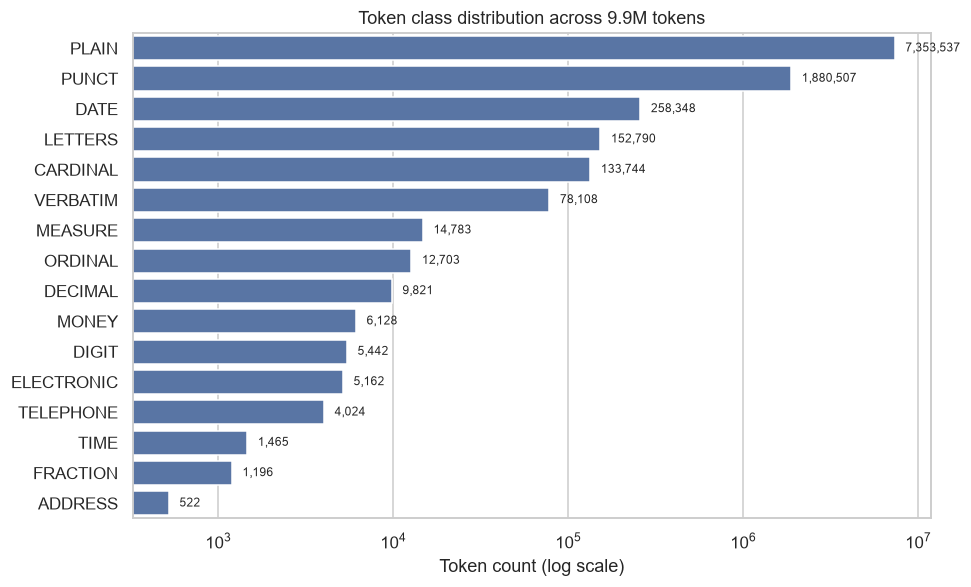

PLAIN and PUNCT alone account for 93.10% of all tokens.


In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax, color=PRIMARY)
ax.set_xscale('log')
ax.set_xlabel('Token count (log scale)')
ax.set_ylabel('')
ax.set_title('Token class distribution across 9.9M tokens')

for i, v in enumerate(counts.values):
    ax.text(v * 1.15, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(ASSETS / 'token_class_distribution.png', bbox_inches='tight')
plt.show()

top2 = pct.head(2)
print(f'{top2.index[0]} and {top2.index[1]} alone account for {top2.sum():.2%} of all tokens.')

---
## 3. How many tokens actually change

This is the single most important number in the dataset, and it determines what any accuracy figure is worth.

In [6]:
df['changed'] = df['before'] != df['after']
unchanged_rate = 1 - df['changed'].mean()

print(f'Tokens passing through unchanged: {unchanged_rate:.2%}')
print(f'Tokens requiring transformation:  {df["changed"].mean():.2%}'
      f'  ({df["changed"].sum():,} tokens)')
print()
print('Implication: a model that copies `before` to `after` and learns nothing')
print(f'scores {unchanged_rate:.2%} accuracy. Any reported figure below that is')
print('worse than doing nothing at all, and figures slightly above it are')
print('mostly measuring the pass-through majority rather than the actual task.')
print()
print('Every model in this project is therefore evaluated twice: overall, and')
print('on the transforming subset alone.')

Tokens passing through unchanged: 93.35%
Tokens requiring transformation:  6.65%  (659,788 tokens)

Implication: a model that copies `before` to `after` and learns nothing
scores 93.35% accuracy. Any reported figure below that is
worse than doing nothing at all, and figures slightly above it are
mostly measuring the pass-through majority rather than the actual task.

Every model in this project is therefore evaluated twice: overall, and
on the transforming subset alone.


### 3.1 Which classes carry the work

Breaking the transformation rate down by class shows where the difficulty is concentrated.

In [7]:
by_class = df.groupby('class', observed=True).agg(
    tokens=('changed', 'size'),
    changed=('changed', 'sum'),
)
by_class['change_rate'] = by_class['changed'] / by_class['tokens']
by_class['share_of_all_changes'] = by_class['changed'] / df['changed'].sum()
by_class = by_class.sort_values('changed', ascending=False)

by_class.style.format({
    'tokens': '{:,}', 'changed': '{:,}',
    'change_rate': '{:.1%}', 'share_of_all_changes': '{:.1%}',
})

,tokens,changed,change_rate,share_of_all_changes
class,,,,
DATE,"258,348","258,348",100.0%,39.2%
LETTERS,"152,790","144,364",94.5%,21.9%
CARDINAL,"133,744","133,744",100.0%,20.3%
PLAIN,"7,353,537","36,472",0.5%,5.5%
VERBATIM,"78,108","25,837",33.1%,3.9%
MEASURE,"14,783","14,761",99.9%,2.2%
ORDINAL,"12,703","12,703",100.0%,1.9%
DECIMAL,"9,821","9,821",100.0%,1.5%
MONEY,"6,128","6,125",100.0%,0.9%


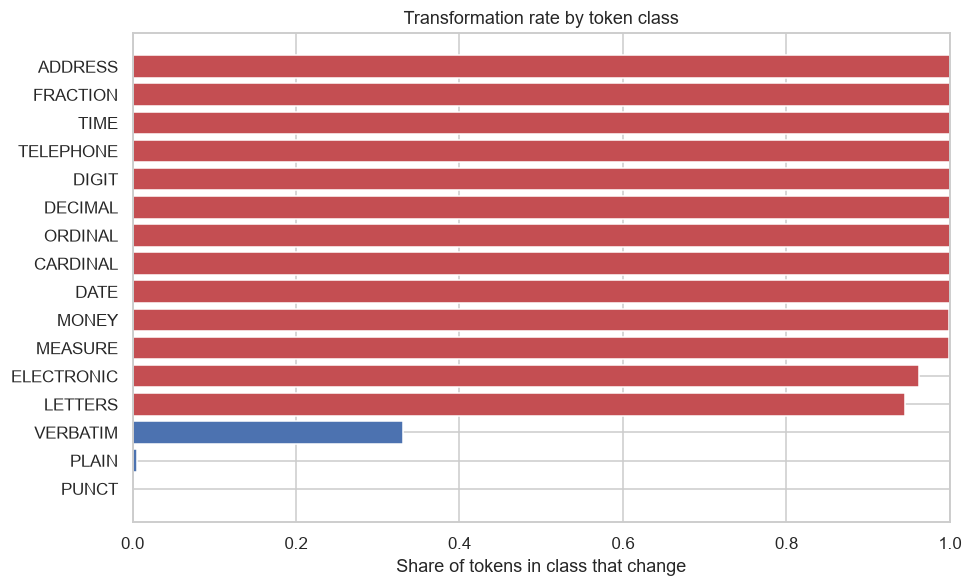

In [8]:
plot_df = by_class[by_class['tokens'] > 100].sort_values('change_rate')

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [ACCENT if r > 0.5 else PRIMARY for r in plot_df['change_rate']]
ax.barh(plot_df.index.astype(str), plot_df['change_rate'], color=colors)
ax.set_xlabel('Share of tokens in class that change')
ax.set_xlim(0, 1)
ax.set_title('Transformation rate by token class')
plt.tight_layout()
plt.savefig(ASSETS / 'change_rate_by_class.png', bbox_inches='tight')
plt.show()

The pattern is close to binary. Some classes are almost entirely pass-through, others almost always transform. That separation is what makes a classify-then-transform pipeline a reasonable design: identifying the class does most of the routing work.

---
## 4. What the transformations look like

Concrete examples per class, which is the fastest way to understand the task.

In [9]:
changed_df = df[df['changed']]

examples = (
    changed_df.groupby('class', observed=True)
    .head(200)
    .drop_duplicates('before')
    .groupby('class', observed=True)
    .head(3)[['class', 'before', 'after']]
    .sort_values('class')
)
examples.reset_index(drop=True)

,class,before,after
0,ADDRESS,M3,m three
1,ADDRESS,A1,a one
2,ADDRESS,I00,i zero
3,CARDINAL,35,thirty five
4,CARDINAL,91,ninety one
5,CARDINAL,3,three
6,DATE,2006,two thousand six
7,DATE,2008,two thousand eight
8,DATE,2007,two thousand seven
9,DECIMAL,1.6,one point six


In [10]:
# A compact set for the README
showcase = ['4-Mar-14', '$3.16', '1987', '12:47', '2006']
readme_examples = (
    changed_df[changed_df['before'].isin(showcase)]
    .drop_duplicates('before')[['before', 'class', 'after']]
)

if len(readme_examples) < 5:
    extra = (changed_df[changed_df['class'].isin(['MONEY', 'DATE', 'TIME', 'MEASURE', 'CARDINAL'])]
             .drop_duplicates('class')[['before', 'class', 'after']])
    readme_examples = pd.concat([readme_examples, extra]).drop_duplicates('before').head(6)

readme_examples.to_csv(ASSETS / 'readme_examples.csv', index=False)
readme_examples

,before,class,after
10,2006,DATE,two thousand six
158,1987,DATE,nineteen eighty seven
95,91,CARDINAL,ninety one
1654,100 m,MEASURE,one hundred meters
1851,"$22,750",MONEY,twenty two thousand seven hundred fifty dollars
3005,3:00 pm,TIME,three p m


---
## 5. Is the mapping deterministic?

A critical question that decides whether this problem can be solved by lookup. If every written form always maps to exactly one spoken form, a dictionary would suffice and machine learning would be unnecessary. Where the same input maps to different outputs, context is required and the ceiling on any context-free model drops.

In [11]:
mapping = changed_df.groupby('before', observed=True)['after'].nunique()
ambiguous = mapping[mapping > 1]

print(f'Distinct written forms that change:        {len(mapping):,}')
print(f'Of those, with more than one spoken form:  {len(ambiguous):,} '
      f'({len(ambiguous) / len(mapping):.2%})')

affected = changed_df['before'].isin(ambiguous.index).mean()
print(f'Share of transforming tokens that are ambiguous: {affected:.2%}')

Distinct written forms that change:        104,214
Of those, with more than one spoken form:  862 (0.83%)
Share of transforming tokens that are ambiguous: 33.76%


In [12]:
# The most ambiguous written forms, and what they map to
worst = ambiguous.sort_values(ascending=False).head(8)

for token in worst.index:
    forms = changed_df[changed_df['before'] == token]['after'].value_counts().head(4)
    print(f'\n{token!r}  ->  {worst[token]} distinct spoken forms')
    for form, n in forms.items():
        print(f'     {n:>7,}  {form}')


'I.'  ->  4 distinct spoken forms
         313  i
          74  one
          43  the first
           1  first

'II'  ->  4 distinct spoken forms
       2,068  two
         347  the second
           8  i i
           8  second

'VIII'  ->  4 distinct spoken forms
          68  eight
          55  the eighth
           2  eighth
           1  v i i i

'XI'  ->  4 distinct spoken forms
          18  the eleventh
           9  eleven
           8  eleventh
           1  x i

'VI'  ->  4 distinct spoken forms
          66  the sixth
          42  six
           4  sixth
           1  v i

'IV'  ->  4 distinct spoken forms
         264  i v
          99  the fourth
          94  four
           8  fourth

'1990'  ->  3 distinct spoken forms
       1,516  nineteen ninety
          22  one thousand nine hundred ninety
           6  one nine nine o

'1996'  ->  3 distinct spoken forms
       2,076  nineteen ninety six
          32  one thousand nine hundred ninety six
           9  one nine

This is the finding that justifies using contextual features rather than a lookup table. Where a written form is ambiguous, no model that sees the token in isolation can resolve it reliably, which sets a hard ceiling on token-level approaches and points toward sequence models as the natural next step.

---
## 6. Token and sentence shape

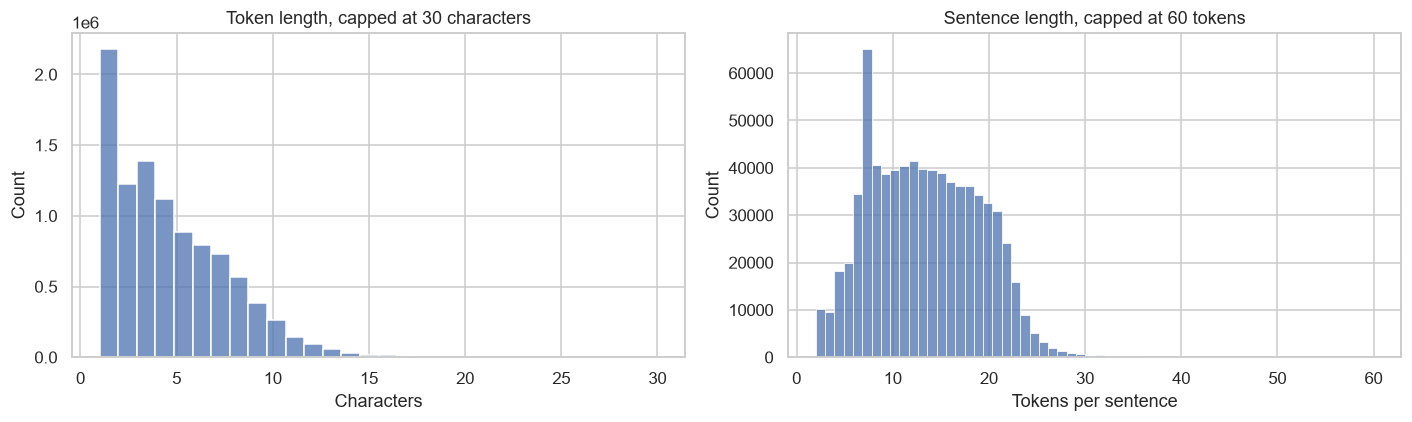

Median token length:    4 characters
99th percentile:        13 characters
Longest token:          1,057 characters
Median sentence length: 13 tokens


In [13]:
df['token_length'] = df['before'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df[df['token_length'] <= 30]['token_length'],
             bins=30, ax=axes[0], color=PRIMARY)
axes[0].set_title('Token length, capped at 30 characters')
axes[0].set_xlabel('Characters')

sentence_lengths = df.groupby('sentence_id')['token_id'].count()
sns.histplot(sentence_lengths[sentence_lengths <= 60],
             bins=60, ax=axes[1], color=PRIMARY)
axes[1].set_title('Sentence length, capped at 60 tokens')
axes[1].set_xlabel('Tokens per sentence')

plt.tight_layout()
plt.savefig(ASSETS / 'token_length_distribution.png', bbox_inches='tight')
plt.show()

print(f'Median token length:    {df["token_length"].median():.0f} characters')
print(f'99th percentile:        {df["token_length"].quantile(0.99):.0f} characters')
print(f'Longest token:          {df["token_length"].max():,} characters')
print(f'Median sentence length: {sentence_lengths.median():.0f} tokens')

---
## 7. Vocabulary growth and unseen tokens

A model that memorises written-to-spoken pairs can only handle what it has seen. Estimating how much of a held-out set will be unfamiliar tells us the ceiling on that strategy.

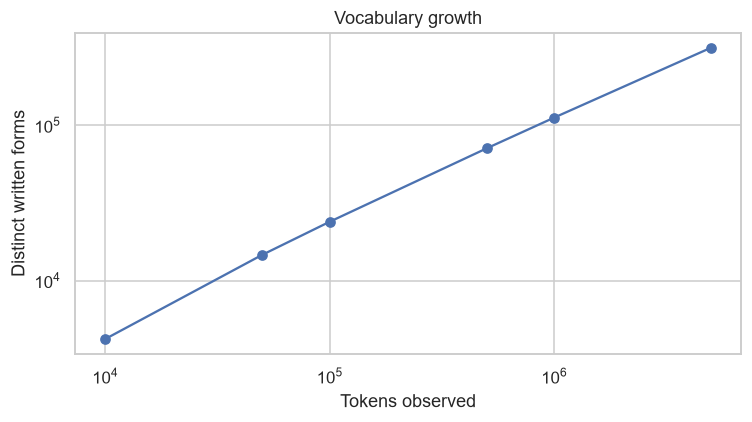

,tokens_seen,unique_forms,ratio
0,"10,000","4,204",0.420
1,"50,000","14,648",0.293
2,"100,000","23,951",0.240
3,"500,000","71,139",0.142
4,"1,000,000","112,287",0.112
5,"5,000,000","316,857",0.063


In [14]:
sample_sizes = [10_000, 50_000, 100_000, 500_000, 1_000_000, 5_000_000]
shuffled = df['before'].sample(frac=1, random_state=RANDOM_STATE).values

growth = [(n, len(set(shuffled[:n]))) for n in sample_sizes if n <= len(shuffled)]
growth_df = pd.DataFrame(growth, columns=['tokens_seen', 'unique_forms'])
growth_df['ratio'] = growth_df['unique_forms'] / growth_df['tokens_seen']

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(growth_df['tokens_seen'], growth_df['unique_forms'],
        marker='o', color=PRIMARY)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Tokens observed')
ax.set_ylabel('Distinct written forms')
ax.set_title('Vocabulary growth')
plt.tight_layout()
plt.savefig(ASSETS / 'vocabulary_growth.png', bbox_inches='tight')
plt.show()

growth_df.style.format({'tokens_seen': '{:,}', 'unique_forms': '{:,}', 'ratio': '{:.3f}'})

In [15]:
# Direct measurement: split by sentence, how much test vocabulary is unseen?
from sklearn.model_selection import GroupShuffleSplit

probe = df.sample(n=min(2_000_000, len(df)), random_state=RANDOM_STATE)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=RANDOM_STATE)
tr_idx, te_idx = next(splitter.split(probe, groups=probe['sentence_id']))
tr, te = probe.iloc[tr_idx], probe.iloc[te_idx]

seen = set(tr['before'])
unseen_all = (~te['before'].isin(seen)).mean()
unseen_changed = (~te[te['changed']]['before'].isin(seen)).mean()

print(f'Held-out tokens never seen in training:              {unseen_all:.2%}')
print(f'Held-out *transforming* tokens never seen:           {unseen_changed:.2%}')
print()
print('The second figure is the one that constrains design. A pure lookup or')
print('memorisation approach fails on all of them, which is the argument for')
print('keeping a generalising rule-based component in the pipeline.')

Held-out tokens never seen in training:              6.54%
Held-out *transforming* tokens never seen:           20.98%

The second figure is the one that constrains design. A pure lookup or
memorisation approach fails on all of them, which is the argument for
keeping a generalising rule-based component in the pipeline.


---
## 8. Building the modeling sample

Training on all 9.9 million tokens is unnecessary for this comparison and makes iteration slow. The sample is drawn at the **sentence** level rather than the token level, for two reasons: it preserves the natural class mix inside each sentence, and it keeps context intact so that no sentence is ever split across a train and test boundary later.

A small version is committed to the repository so the modeling notebook runs without the full download.

In [16]:
TARGET_TOKENS = 200_000

rng = np.random.default_rng(RANDOM_STATE)
all_sentences = df['sentence_id'].unique()
rng.shuffle(all_sentences)

sizes = df.groupby('sentence_id')['token_id'].count()
cumulative = sizes.reindex(all_sentences).cumsum()
chosen = cumulative[cumulative <= TARGET_TOKENS].index

sample = df[df['sentence_id'].isin(chosen)][
    ['sentence_id', 'token_id', 'class', 'before', 'after']
].copy()

print(f'Sample: {len(sample):,} tokens from {sample["sentence_id"].nunique():,} sentences')
print(f'Unchanged rate in sample: {(sample["before"] == sample["after"]).mean():.2%}'
      f'   (full corpus: {unchanged_rate:.2%})')

comparison = pd.DataFrame({
    'full_corpus': df['class'].value_counts(normalize=True),
    'sample': sample['class'].value_counts(normalize=True),
}).fillna(0)
comparison['difference'] = (comparison['sample'] - comparison['full_corpus']).abs()
comparison.sort_values('full_corpus', ascending=False).style.format('{:.4%}')

Sample: 199,999 tokens from 15,061 sentences
Unchanged rate in sample: 93.41%   (full corpus: 93.35%)


,full_corpus,sample,difference
class,,,
PLAIN,74.1413%,74.3109%,0.1696%
PUNCT,18.9600%,18.9731%,0.0131%
DATE,2.6048%,2.5520%,0.0528%
LETTERS,1.5405%,1.5305%,0.0100%
CARDINAL,1.3485%,1.3895%,0.0410%
VERBATIM,0.7875%,0.6315%,0.1560%
MEASURE,0.1490%,0.1495%,0.0005%
ORDINAL,0.1281%,0.1405%,0.0124%
DECIMAL,0.0990%,0.0855%,0.0135%


The sample tracks the full corpus closely on both the unchanged rate and the class mix, which is the check that matters. If it did not, every downstream metric would describe a different distribution from the one the task actually presents.

In [17]:
sample.to_csv('../data/sample_en_train.csv', index=False)
print(f'Wrote ../data/sample_en_train.csv  '
      f'({Path("../data/sample_en_train.csv").stat().st_size / 1e6:.1f} MB)')

print('\nCharts written to ../assets/:')
for f in sorted(ASSETS.glob('*.png')):
    print(f'  {f.name}')

Wrote ../data/sample_en_train.csv  (5.6 MB)

Charts written to ../assets/:
  change_rate_by_class.png
  token_class_distribution.png
  token_length_distribution.png
  vocabulary_growth.png


---
## Summary of findings

Fill in the numbers from your run:

| Finding | Value | Consequence for modeling |
|---|---|---|
| Corpus size | | |
| Tokens unchanged | | Sets the do-nothing baseline that every model must beat |
| Classes covering most transformations | | Where modeling effort should concentrate |
| Ambiguous written forms | | Bounds what any context-free model can achieve |
| Unseen transforming tokens in held-out data | | Argues for a generalising fallback rather than pure memorisation |

Next: `02_modeling.ipynb`.

In [18]:
print(by_class.to_string())
print()
print(comparison.sort_values('full_corpus', ascending=False).to_string())

             tokens  changed  change_rate  share_of_all_changes
class                                                          
DATE         258348   258348     1.000000              0.391562
LETTERS      152790   144364     0.944852              0.218804
CARDINAL     133744   133744     1.000000              0.202708
PLAIN       7353537    36472     0.004960              0.055278
VERBATIM      78108    25837     0.330786              0.039160
MEASURE       14783    14761     0.998512              0.022372
ORDINAL       12703    12703     1.000000              0.019253
DECIMAL        9821     9821     1.000000              0.014885
MONEY          6128     6125     0.999510              0.009283
DIGIT          5442     5442     1.000000              0.008248
ELECTRONIC     5162     4964     0.961643              0.007524
TELEPHONE      4024     4024     1.000000              0.006099
TIME           1465     1465     1.000000              0.002220
FRACTION       1196     1196     1.00000